In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("final_food_delivery_dataset.csv")
df.head()

,order_id,user_id,restaurant_id,order_date,total_amount,restaurant_name_x,name,city,membership,restaurant_name_y,cuisine,rating
0,1,2508,450,18-02-2023,842.97,New Foods Chinese,User_2508,Hyderabad,Regular,Restaurant_450,Mexican,3.2
1,2,2693,309,18-01-2023,546.68,Ruchi Curry House Multicuisine,User_2693,Pune,Regular,Restaurant_309,Indian,4.5
2,3,2084,107,15-07-2023,163.93,Spice Kitchen Punjabi,User_2084,Chennai,Gold,Restaurant_107,Mexican,4.0
3,4,319,224,04-10-2023,1155.97,Darbar Kitchen Non-Veg,User_319,Bangalore,Gold,Restaurant_224,Chinese,4.8
4,5,1064,293,25-12-2023,1321.91,Royal Eatery South Indian,User_1064,Pune,Regular,Restaurant_293,Italian,3.0


In [3]:
df.shape

(10000, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   restaurant_id      10000 non-null  int64  
 3   order_date         10000 non-null  str    
 4   total_amount       10000 non-null  float64
 5   restaurant_name_x  10000 non-null  str    
 6   name               10000 non-null  str    
 7   city               10000 non-null  str    
 8   membership         10000 non-null  str    
 9   restaurant_name_y  10000 non-null  str    
 10  cuisine            10000 non-null  str    
 11  rating             10000 non-null  float64
dtypes: float64(2), int64(3), str(7)
memory usage: 937.6 KB


In [5]:
df.describe()

,order_id,user_id,restaurant_id,total_amount,rating
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1504.117700,251.016700,801.162412,4.045430
std,2886.89568,861.727776,144.622558,405.458753,0.606531
min,1.00000,1.000000,1.000000,100.200000,3.000000
25%,2500.75000,761.000000,127.000000,446.310000,3.500000
50%,5000.50000,1508.000000,251.000000,806.295000,4.100000
75%,7500.25000,2250.250000,376.000000,1149.227500,4.600000
max,10000.00000,3000.000000,500.000000,1499.830000,5.000000


In [6]:
df.isnull().sum()

order_id             0
user_id              0
restaurant_id        0
order_date           0
total_amount         0
restaurant_name_x    0
name                 0
city                 0
membership           0
restaurant_name_y    0
cuisine              0
rating               0
dtype: int64

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
total_orders = df.shape[0]
total_orders

10000

In [9]:
df['user_id'].nunique()

2883

In [10]:
df[df['membership'] == 'Gold'].shape[0]

4987

In [11]:
round(df[df['membership'] == 'Gold']['total_amount'].mean(), 2)

np.float64(797.15)

In [12]:
df.groupby('city')['total_amount'].sum().sort_values(ascending=False)

city
Bangalore    2206946.58
Chennai      1990513.03
Pune         1924797.93
Hyderabad    1889366.58
Name: total_amount, dtype: float64

In [13]:
df[df['membership'] == 'Gold'].groupby('city')['total_amount'].sum().idxmax()

'Chennai'

In [14]:
df.groupby('cuisine')['total_amount'].mean().sort_values(ascending=False)

cuisine
Mexican    808.021344
Italian    799.448578
Indian     798.466011
Chinese    798.389020
Name: total_amount, dtype: float64

In [15]:
df.groupby('cuisine').agg(
    restaurants=('restaurant_id', 'nunique'),
    revenue=('total_amount', 'sum')
).sort_values(by='restaurants')

,restaurants,revenue
cuisine,,
Chinese,120,1930504.65
Indian,126,1971412.58
Italian,126,2024203.80
Mexican,128,2085503.09


In [16]:
df[df['rating'] >= 4.5].shape[0]

3374

In [17]:
bins = [3.0, 3.5, 4.0, 4.5, 5.0]
labels = ['3.0–3.5', '3.6–4.0', '4.1–4.5', '4.6–5.0']

df['rating_range'] = pd.cut(df['rating'], bins=bins, labels=labels)
df.groupby('rating_range')['total_amount'].sum()

rating_range
3.0–3.5    1881754.57
3.6–4.0    1717494.41
4.1–4.5    1960326.26
4.6–5.0    2197030.75
Name: total_amount, dtype: float64

In [21]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['quarter'] = df['order_date'].dt.to_period('Q')

df.groupby('quarter')['total_amount'].sum()

quarter
2023Q1    1993425.14
2023Q2    1945348.72
2023Q3    2037385.10
2023Q4    2018263.66
2024Q1      17201.50
Freq: Q-DEC, Name: total_amount, dtype: float64

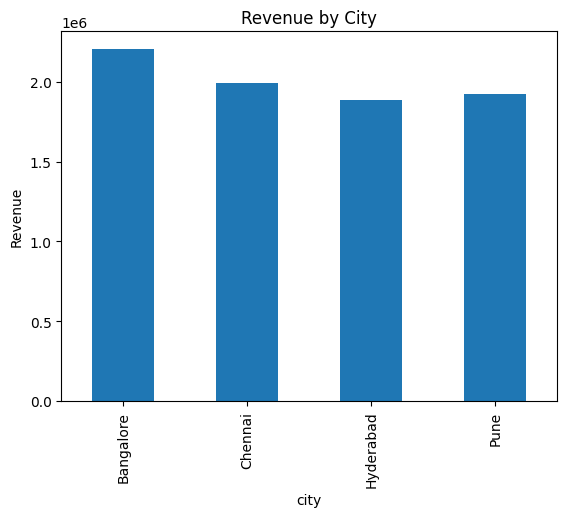

In [22]:
df.groupby('city')['total_amount'].sum().plot(kind='bar')
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.show()